https://velog.io/@woooa/TIL-%EB%B2%A0%EC%9D%B4%EC%A6%88-%EC%A0%95%EB%A6%AC

https://ablearn.kr/insight/?bmode=view&idx=13428641

In [71]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.naive_bayes import CategoricalNB


def draw_bayes_square(df):

    # -------------------
    # 자동 분리
    # -------------------

    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    feature = X.columns[0]
    target = y.name

    # -------------------
    # 학습
    # -------------------

    model = CategoricalNB(alpha=0)

    model.fit(X, y)

    # -------------------
    # 확률
    # -------------------

    prior = np.exp(
        model.class_log_prior_
    )

    p_y0 = prior[0]
    p_y1 = prior[1]

    cond = np.exp(
        model.feature_log_prob_[0]
    )

    p_x0_y0 = cond[0][0]
    p_x1_y0 = cond[0][1]

    p_x0_y1 = cond[1][0]
    p_x1_y1 = cond[1][1]

    # -------------------
    # 면적
    # -------------------

    areas = [

        p_y1 * p_x1_y1,
        p_y1 * p_x0_y1,

        p_y0 * p_x1_y0,
        p_y0 * p_x0_y0
    ]

    sns.set_theme(style="white")

    fig, ax = plt.subplots(
        figsize=(9, 9)
    )

    colors = sns.color_palette(
        "pastel",
        4
    )

    boxes = [

        (
            (0, p_x0_y1),
            p_y1,
            p_x1_y1,
            colors[0],
            f"{target}=1\n{feature}=1\n{areas[0]:.2f}"
        ),

        (
            (0, 0),
            p_y1,
            p_x0_y1,
            colors[1],
            f"{target}=1\n{feature}=0\n{areas[1]:.2f}"
        ),

        (
            (p_y1, p_x0_y0),
            p_y0,
            p_x1_y0,
            colors[2],
            f"{target}=0\n{feature}=1\n{areas[2]:.2f}"
        ),

        (
            (p_y1, 0),
            p_y0,
            p_x0_y0,
            colors[3],
            f"{target}=0\n{feature}=0\n{areas[3]:.2f}"
        )
    ]

    for pos, w, h, color, txt in boxes:

        ax.add_patch(

            Rectangle(
                pos,
                w,
                h,
                facecolor=color,
                edgecolor="black",
                linewidth=3
            )

        )

        ax.text(
            pos[0] + w/2,
            pos[1] + h/2,
            txt,
            ha="center",
            va="center",
            fontsize=13
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(
        f"{feature} × {target}"
    )

    plt.show()

In [72]:
import pandas as pd
from sklearn.naive_bayes import BernoulliNB

# -----------------
# 데이터 생성
# travel
# 1 = 여행
# 0 = 비여행
#
# like
# 1 = 좋아요
# 0 = 싫어요
# -----------------

# import pandas as pd

# df = pd.DataFrame({

#     "평가": [
#         "좋아요","좋아요","좋아요","좋아요","좋아요",
#         "좋아요","좋아요","좋아요","좋아요","좋아요",

#         "싫어요","싫어요","싫어요","싫어요","싫어요",
#         "싫어요","싫어요","싫어요","싫어요","싫어요"
#     ],

#     "콘텐츠": [
#         "여행","여행","여행","여행","여행",
#         "여행","여행","여행","비여행","비여행",

#         "여행","여행","여행","여행",
#         "비여행","비여행","비여행",
#         "비여행","비여행","비여행"
#     ]

# })

# print(df)

df = pd.DataFrame({
    "travel": [1,1,1,1,1,1,1,1,0,0,  1,1,1,1,0,0,0,0,0,0],
    "like":   [1,1,1,1,1,1,1,1,1,1,  0,0,0,0,0,0,0,0,0,0]  # 사전확률
})

print(df)
print(df["like"].value_counts(normalize=True))

    travel  like
0        1     1
1        1     1
2        1     1
3        1     1
4        1     1
5        1     1
6        1     1
7        1     1
8        0     1
9        0     1
10       1     0
11       1     0
12       1     0
13       1     0
14       0     0
15       0     0
16       0     0
17       0     0
18       0     0
19       0     0
like
1    0.5
0    0.5
Name: proportion, dtype: float64


```
전체 확률 = 1

┌──────────────┐
│      │       │
│0.5   │ 0.5   │
│좋아요 │싫어요  │
└──────────────┘

 그 다음 세로를 조건부확률로 자르는 거임

좋아요 영역:

0.8 여행
0.2 비여행

싫어요 영역:

0.4 여행
0.6 비여행

그래서 넓이:

0.5 × 0.8 = 0.4
0.5 × 0.2 = 0.1
0.5 × 0.4 = 0.2
0.5 × 0.6 = 0.3

가 됨

즉, 데이터에서는 like 컬럼의 비율 자체가 사전확률 P(👍) 로 표현.
```

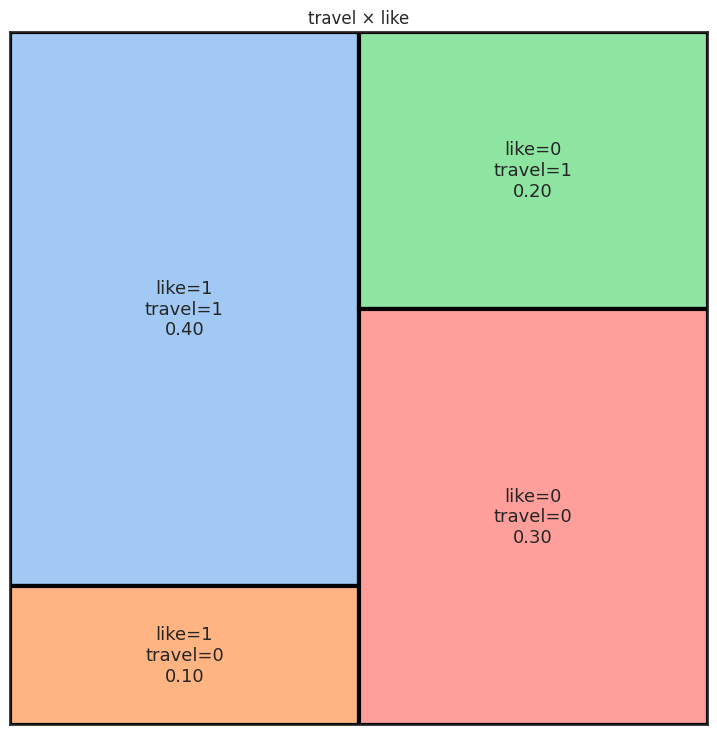

In [73]:
x = df[["travel"]]
y = df["like"]

model = BernoulliNB(alpha=0)


model.fit(x, y)

draw_bayes_square(df)

In [74]:
# 여행 콘텐츠일때 좋아할 확률
model.predict([[1]])  
# [1] => 좋아요 예측

prob = model.predict_proba([[1]])

print(prob)  # 확률 보기 
# [[0.35714286 0.64285714]]

# P(👍∣🛫)=66.7%


[[0.33333333 0.66666667]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


In [75]:
# 여행 콘텐츠일때 싫어할 확률
prob = model.predict_proba([[0]])

print(prob)

# | 결과  | 확률  |
# | --- | --- |
# | 싫어요 | 70% |
# | 좋아요 | 30% |


[[0.75 0.25]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


In [76]:
# 문제 3 — 음식 추천 🍕

# 사용자 음식 기록

# 총 20개

# 좋아함 10개
#  - 매운 음식 9개
#  - 안 매움 1개

# 싫어함 10개
#  - 매운 음식 4개
#  - 안 매움 6개

# 문제
# P(매움∣좋아함)
# P(좋아함∣매움)
# 정사각형 면적으로 시각화
# BernoulliNB 예측

# 데이터:

# ① 손계산
# ↓
# ② 정사각형 면적
# ↓
# ③ BernoulliNB
# ↓
# ④ predict_proba()

In [77]:
import pandas as pd
from sklearn.naive_bayes import BernoulliNB


# -------------------------
# 음식 데이터
# spicy
# 1 = 매움
# 0 = 안매움
#
# like
# 1 = 좋아함
# 0 = 싫어함
# -------------------------

df = pd.DataFrame({

    "spicy":[
        1,1,1,1,1,1,1,1,1,0,
        1,1,1,1,0,0,0,0,0,0
    ],

    "like":[
        1,1,1,1,1,1,1,1,1,1,
        0,0,0,0,0,0,0,0,0,0
    ]

})

print(df)


X = df[["spicy"]]
y = df["like"]

model = BernoulliNB(alpha=0)

model.fit(X, y)

    spicy  like
0       1     1
1       1     1
2       1     1
3       1     1
4       1     1
5       1     1
6       1     1
7       1     1
8       1     1
9       0     1
10      1     0
11      1     0
12      1     0
13      1     0
14      0     0
15      0     0
16      0     0
17      0     0
18      0     0
19      0     0


BernoulliNB(alpha=0)

In [ ]:
pred = model.predict([[1]])
prob = model.predict_proba([[1]])

print(
    "예측:",
    pred
)

print(
    "확률:",
    prob
)

# 매운 음식 추천

# 싫어할 확률 → 31%
# 좋아할 확률 → 69%

예측: [1]
확률: [[0.30769231 0.69230769]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


In [79]:
# P(매움 | 좋아함)

p_spicy_given_like = (
    ((df["spicy"]==1) &
     (df["like"]==1)).sum()
    /
    (df["like"]==1).sum()
)

print(
    "P(매움|좋아함)=",
    round(p_spicy_given_like, 2)
)


# P(좋아함)

p_like = (
    (df["like"]==1)
    .mean()
)

print(
    "P(좋아함)=",
    round(p_like, 2)
)


# P(좋아함 | 매움)

p_like_given_spicy = (

    ((df["spicy"]==1)
     &
     (df["like"]==1)).sum()

    /

    (df["spicy"]==1).sum()

)

print(
    "P(좋아함|매움)=",
    round(p_like_given_spicy, 2)
)

P(매움|좋아함)= 0.9
P(좋아함)= 0.5
P(좋아함|매움)= 0.69
